In [467]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [468]:
from sklearn.datasets import load_iris
dataset=load_iris()
df=pd.DataFrame(data=dataset.data,columns=dataset.feature_names)
df['target'] = dataset.target

In [469]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [470]:
X=df.drop('target',axis=1)
y=df['target']

In [471]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [472]:
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import r2_score

lr=LinearRegression()
ridge=Ridge(alpha=10)

lr.fit(X_train,y_train)
ridge.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

print(r2_score(y_test,y_pred_lr))
print(r2_score(y_test,y_pred_ridge))

0.9442318571467434
0.9320290183586611


In [473]:
lr.intercept_,lr.coef_

(np.float64(0.18080804062268085),
 array([-0.10753506, -0.05844926,  0.2647557 ,  0.52929416]))

In [474]:
ridge.intercept_,ridge.coef_

(np.float64(-0.17336741145268042),
 array([-0.03983067, -0.0531871 ,  0.33232646,  0.27201646]))

## SCRATCH

In [475]:
class Linear():
    def __init__(self):
        self.intercept_ = None
        self.coef_ = None

    def fit(self,X_train,y_train):
        X = np.hstack((np.ones((X_train.shape[0], 1)),X_train))

        # I = np.eye(X.shape(1))
        # I[0,0] = 0

        m = np.linalg.inv(X.T @ X) @ (X.T @ y_train)

        self.coef_ = m[1:]
        self.intercept_ = m[0]
    

In [476]:
model = Linear()
model.fit(X_train,y_train)
model.intercept_,model.coef_

(np.float64(0.18080804062260422),
 array([-0.10753506, -0.05844926,  0.2647557 ,  0.52929416]))

In [477]:
class Ridge_Reg:
    def __init__(self,alpha):
        self.alpha=alpha
        self.intercept_ = None
        self.coef_ = None
    
    def fit(self,X_train,y_train):
        X = np.hstack((np.ones((X_train.shape[0], 1)),X_train))

        I = np.eye(X.shape[1])
        I[0,0] = 0

        m = np.linalg.inv(X.T @ X + self.alpha * I) @ (X.T @ y_train)

        self.coef_ = m[1:]
        self.intercept_ = m[0]

In [478]:
model1 = Ridge_Reg(10)
model1.fit(X_train,y_train)
model1.intercept_,model1.coef_

(np.float64(-0.1733674114526829),
 array([-0.03983067, -0.0531871 ,  0.33232646,  0.27201646]))

### USING GRADIENT DESCENT

In [479]:
from sklearn.datasets import make_regression

In [480]:
X1,y1 = make_regression(n_features=1,n_samples=100,random_state=10,noise=10)

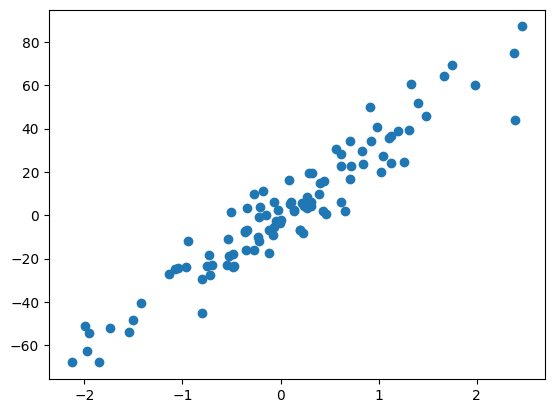

In [481]:
plt.scatter(X1,y1)

In [482]:
X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1,test_size=0.3,random_state=42)

In [483]:
class LRegressor:
    def __init__(self, eta, epoch):
        self.eta = eta
        self.epoch = epoch
        self.m = 0
        self.b = 0

    def fit(self, X_train, y_train):
        n = len(X_train)

        for _ in range(self.epoch):
            y_pred = self.m * X_train + self.b

            dm = (1/n) * np.sum((y_pred - y_train) * X_train)
            db = (1/n) * np.sum(y_pred - y_train)

            self.m -= self.eta * dm
            self.b -= self.eta * db


In [484]:
model2 = LRegressor(0.01,1000)
model2.fit(X1_train,y1_train)
print(model2.m,model2.b)

-1.1776741577832785e-16 3.4557234945008646


In [485]:
class RRegressor:
    def __init__(self, eta, epoch,alpha):
        self.eta = eta
        self.epoch = epoch
        self.alpha = alpha
        self.m = 0
        self.b = 0

    def fit(self, X_train, y_train):
        n = len(X_train)

        for _ in range(self.epoch):
            y_pred = self.m * X_train + self.b

            dm = (1/n) * np.sum((y_pred - y_train) * X_train) + (2 * self.alpha * self.m)
            db = (1/n) * np.sum(y_pred - y_train)

            self.m -= self.eta * dm
            self.b -= self.eta * db

In [486]:
model3 = RRegressor(0.001,1000,10)
model3.fit(X1_train,y1_train)
print(model3.m,model3.b)

2.689923834234283e-16 3.455723494500862
